In [1]:
import tensorflow as tf
from tensorflow.python.ops import math_ops
from tensorflow.keras import backend as K
import numpy as np
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import math
from tqdm import trange

In [2]:
batch_size = 32
epochs = 5000
optimizer = Adam(learning_rate=0.001)
weight_init = RandomNormal()

In [3]:
#boundary condition:
R = 1.2 #resistence,kohm
L = 1.5 #inductance,H
C = 0.3 #capacitance,F
VC_0 = 12.0 #initial_volt,V

# initial time/current condition:
t_init = np.array([[0.0]], dtype=np.float32)
i_init = np.array([[0.0]], dtype=np.float32)

# initial time/voltage condition:
t_initv = np.array([[0.0]], dtype=np.float32)
v_initv = np.array([[VC_0]], dtype=np.float32)

# colocation points
t_col = np.arange(0, 20.0, 0.1, dtype=np.float32).reshape(-1, 1)

In [4]:
#輸入層
input = tf.keras.Input(shape=(1,))
#第一層神經層
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init, kernel_regularizer=None)(input)
#第二層神經層
x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init, kernel_regularizer=None)(x)
#輸出層
output = layers.Dense(1, activation='linear', kernel_initializer=weight_init, kernel_regularizer=None)(x)
model = tf.keras.Model(inputs=input, outputs=output)

In [5]:
@tf.function
def step(t_col, t_init, i_init, t_initv, v_initv):
    with tf.GradientTape() as tape_w:

        # 第一個 Loss: i(0) = 0
        pred_init = model(t_init)
        #計算預測值和理論值方均根
        init_loss = tf.reduce_mean(tf.square(pred_init - i_init))

        # 第二個 Loss: L * di/dt(0) = VC_0
        with tf.GradientTape() as tape_t_init:
            #使微分器追縱時間數據
            tape_t_init.watch(t_initv)
            pred_initv = model(t_initv)
        dfdx = tape_t_init.gradient(pred_initv, t_initv)
        #確保電感L的資料型態也是float32，並乘上我們微分得出的di/dt
        v = dfdx * tf.cast(L, tf.float32)
        init_lossv = tf.reduce_mean(tf.square(v - v_initv))

        # 第三個 Loss: PINN 物理方程式 (內層 Tape 算時間導數)
        with tf.GradientTape() as tape_t2:
            tape_t2.watch(t_col)
            with tf.GradientTape() as tape_t1:
                tape_t1.watch(t_col)
                pred_q = model(t_col)
            dqdt = tape_t1.gradient(pred_q, t_col)
        dq2dt = tape_t2.gradient(dqdt, t_col)
        # RLC 物理方程式
        Residual = dq2dt + dqdt * (R/L) + pred_q / (L * C)
        pinn_loss = tf.reduce_mean(tf.square(Residual))

        # 組合所有 Loss (可考慮為 PINN loss 加上權重)
        model_loss = init_loss + init_lossv + pinn_loss

    # 反向傳播與更新模型
    trainable = model.trainable_variables
    #計算出每個神經元修正梯度
    grads = tape_w.gradient(model_loss, trainable)
    #將梯度與神經元匹配並透過optimizer套用
    optimizer.apply_gradients(zip(grads, trainable))

    return model_loss

In [6]:
data_size = len(t_col)
#計算每次迭代輸入資料量(無條件)
steps_per_epoch = math.ceil(data_size / batch_size)

#定義每筆數據訓練幾次
for epoch in trange(epochs):

    #打亂t_col內的資料順序避免過度擬和
    indices = np.random.permutation(data_size)
    #將打亂的資料重新排列
    t_col_shuffled = t_col[indices]

    for i in range(steps_per_epoch):
        start_idx = i * batch_size

        end_idx = min(start_idx + batch_size, data_size)

        t_col_batch = t_col_shuffled[start_idx:end_idx]

        loss = step(t_col_batch, t_init, i_init, t_initv, v_initv)

100%|██████████| 5000/5000 [03:47<00:00, 21.95it/s]


In [7]:
numb_of_pts = 1000

t_test = np.linspace(0, 20, numb_of_pts).astype(np.float32)
t_test_in = t_test.reshape(-1, 1)

i_test = model(t_test_in, training=False).numpy().reshape(-1)

alpha = R / (2 * L)
w0 = np.sqrt(1 / (L * C))
wd = np.sqrt(w0**2 - alpha**2)
i_calc = (VC_0 / (L * wd)) * np.exp(-alpha * t_test) * np.sin(wd * t_test)

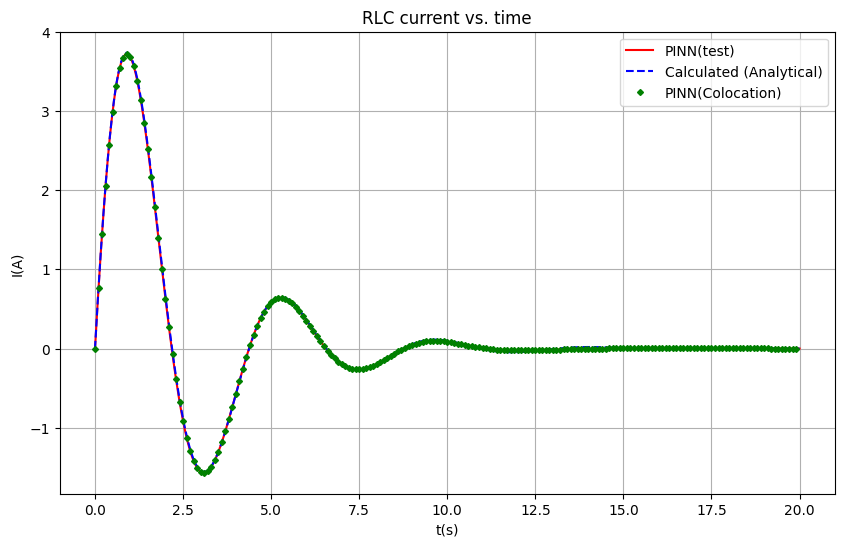

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(t_test, i_test, 'r', label='PINN(test)')
plt.plot(t_test, i_calc, 'b--', label='Calculated (Analytical)')
plt.plot(t_col, model(t_col).numpy(), 'Dg', markersize=3, label='PINN(Colocation)')
plt.title('RLC current vs. time')
plt.xlabel('t(s)')
plt.ylabel('I(A)')
plt.legend()
plt.grid()
plt.show()